In [1]:
import jax
print("JAX devices:", jax.devices())
print("Default backend:", jax.default_backend())

JAX devices: [CudaDevice(id=0)]
Default backend: gpu


W1119 17:45:05.590787   10816 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1119 17:45:05.594297   10788 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


In [2]:
# Enable autoreload of local Python modules (e.g., models)
%load_ext autoreload
%autoreload 2

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import jax
import jax.numpy as jnp
import optax
import time

# local imports
import models.models2 as models
import util.generation as generation

In [4]:
# initialize the jax random key
key = jax.random.key(0)

# Load data

In [5]:
# load the ./data/text8_train.txt and ./data/text8_test.txt files
with open("./data/text8_train.txt", "r") as f:
    train_text = f.read()
with open("./data/text8_test.txt", "r") as f:
    test_text = f.read()

# print the length of the training text and test text
print(f"Length of training text: {len(train_text):_} characters")
print(f"Length of test text: {len(test_text):_} characters")

Length of training text: 90_000_000 characters
Length of test text: 5_000_000 characters


In [7]:
# Build vocabulary (lowercase + space + a few punctuations)
char_set = list("abcdefghijklmnopqrstuvwxyz ")
char_to_int = {ch:i for i,ch in enumerate(char_set)}
int_to_char = {i:ch for ch,i in char_to_int.items()}

def encode(s):
    """Encode string to array of integers"""
    ids = [char_to_int[c] for c in s]
    return np.array(ids, dtype=np.uint8)  # use np.uint8 to save space

In [8]:
# encode the text
train_text_int = encode(train_text)
test_text_int = encode(test_text)

In [9]:
# sanity check: display a few random characters from the training text
T = 128
for _ in range(5):
    # choose random position in text
    N = np.random.randint(low=0, high=len(train_text)-T)
    print(train_text[N:N+T])
    print()

s a total of three on one five december one nine three eight this changed to five from which three were chosen for insertion in 

or faramir and owyn walked together in the gardens nearly every day and he learned from merry brandybuck of owyn s despair of fe

is head is believed to be now in italy his right hand at etchmiadzin and his left at sis it is almost impossible to get at grego

ght seven year old jackson scholz when cross says something about beating scholz the latter remarks you never beat me with mock 

 oil trust was split into three four companies two of these companies were jersey standard which eventually became exxon and soc



# Create a basic Transformer model

In [10]:
def create_train_state(
    rng,
    vocab_size=27,
    d_model=64,
    n_layers=6,
    n_heads=8,
    max_len=128,
    dropout=0.1,
    mem_len=512,
):
    # create an XLMemoryTransformer model
    model = models.XLMemoryTransformer(
        vocab_size=vocab_size,
        d_model=d_model,
        n_layers=n_layers,
        n_heads=n_heads,
        mem_len=mem_len,
        dropout=dropout,
        mlp_mult=2.667,
    )
    # create a dummy input for initialization
    dummy = jnp.zeros((1, min(16, max_len)), dtype=jnp.int32)
    # pass the dummy input to the model to initialize the parameters
    variables = model.init({"params": rng}, dummy, deterministic=True)
    params = variables["params"]
    return model, params

In [11]:
# vocab size
vocab_size= len(char_set)

# internal model dimensions
d_model=256

# number of attention heads
n_heads=8

# number of Transformer layers
n_layers=2

# maximum sequence length
max_len=128

model, params = create_train_state(key, vocab_size, d_model, n_layers, n_heads, max_len)

In [12]:
# compute the number of parameters
def count_params(params):
    return sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"Number of parameters: {count_params(params):_}")

Number of parameters: 1_580_546


In [13]:
# sanity check: create a batch of data & run a forward pass
B, T = 4, 32
batch = jax.random.randint(
    key=key,
    shape=(B, T), minval=0, maxval=len(char_set))
logits, _ = model.apply({"params": params}, batch)


print("batch shape:", batch.shape)  # (B, T)
print("logits shape:", logits.shape)  # (B, T, vocab_size)

batch shape: (4, 32)
logits shape: (4, 32, 27)


# Loss function

In [14]:
@jax.jit
def loss_and_metrics(logits, targets):
    """Compute cross-entropy loss and accuracy.

    Assumes `targets` contains only valid integer class ids in [0, V-1] (no -1 ignore tokens).

    Args:
      logits: (B, T, V) float array of unnormalized scores.
      targets: (B, T) integer array with ground-truth class ids.

    Returns:
      loss: scalar average cross-entropy over all positions.
      metrics: dict with keys "loss" and "acc" (both scalars).
    """
    # Flatten batch/time dims so optax works on shape (N, V) and (N,)
    vocab = logits.shape[-1]
    flat_logits = logits.reshape(-1, vocab)
    flat_targets = targets.reshape(-1)

    # Per-position cross-entropy, then mean over all positions
    per_pos = optax.softmax_cross_entropy_with_integer_labels(flat_logits, flat_targets)
    loss = per_pos.mean()

    # prediction over all positions
    preds = jnp.argmax(logits, axis=-1)  # (B, T)
    
    # compute accuracy over only the last position
    is_match = preds == targets
    
    # Accuracy over all positions
    acc_all = jnp.mean(is_match.astype(jnp.float32))
    
    # Accuracy over only last position
    acc_last = jnp.mean(is_match.astype(jnp.float32)[:,-1])

    return loss, {"loss": loss, "acc": acc_all, "acc_last": acc_last}

# Optimization step:

In [15]:
# create an update function
def train_step(params, opt_state, x, y, tx):
    """Single optimization step using optax optimizer.

    Args:
      params: pytree of model parameters.
      opt_state: optax optimizer state corresponding to `params`.
      x: (B, T) int array input tokens.
      y: (B, T) int array target tokens.
      tx: optax.GradientTransformation (already initialized).

    Returns:
      new_params: updated parameters after one gradient step.
      new_opt_state: updated optimizer state.
      metrics: dict of scalar metrics (loss, acc).
    """
    def loss_fn(params):
        logits, _ = model.apply({"params": params}, x)
        loss, metrics = loss_and_metrics(logits, y)
        return loss, metrics

    # compute gradients (loss is scalar, metrics is auxiliary)
    (loss, metrics), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # optax update: compute parameter updates and new optimizer state
    updates, new_opt_state = tx.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, metrics

# jit: last argument should be static because it is an object
train_step = jax.jit(train_step, static_argnames=("tx",))

# Batch creation:

In [16]:
# create a batch from the training data
def get_batch(text_int, B, T):
    """Create a random batch of data from text_int.

    Args:
      text_int: 1D array of token ids.
      B: batch size (number of sequences).
      T: sequence length (number of tokens per sequence).

    Returns:
      x: (B, T) int array input tokens.
      y: (B, T) int array target tokens.
    """
    # choose random starting indices for each sequence in the batch
    ix = np.random.randint(0, len(text_int) - T, size=B)
    # inputs are text from i to i+T
    x = np.stack([text_int[i:i+T] for i in ix])
    # targets are text from i+1 to i+T+1
    y = np.stack([text_int[i+1:i+T+1] for i in ix])
    return jnp.array(x, dtype=jnp.int32), jnp.array(y, dtype=jnp.int32)

In [26]:
def run_single_config(
    config,
    train_text_int,
    test_text_int,
    base_key,
    niter_search=2000,
    B=128,
    B_test=512,
    eval_every=200,
):
    print("\n=== Running config:", config, "===\n")

    T = config["T"]
    T_test = config["T"]

    key_init, key_train = jax.random.split(base_key)

    model, params = create_train_state(
        key_init,
        vocab_size=config["vocab_size"],
        d_model=config["d_model"],
        n_layers=config["n_layers"],
        n_heads=config["n_heads"],
        max_len=config["max_len"],   # keep ≥ max T
        dropout=config["dropout"],
    )

    if config["opt"] == "adamw":
        lr = config["learning_rate"]
        tx = optax.adamw(learning_rate=lr, weight_decay=config["weight_decay"])
    else:
        lr = config["learning_rate"]
        tx = optax.adam(learning_rate=lr)

    opt_state = tx.init(params)

    @jax.jit
    def train_step_local(params, opt_state, x, y):
        def loss_fn(p):
            logits, _ = model.apply({"params": p}, x)
            loss, metrics = loss_and_metrics(logits, y)
            return loss, metrics

        (loss, metrics), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
        updates, new_opt_state = tx.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, metrics

    best_test_loss = None

    for it in range(1, niter_search + 1):
        # training batch with per-config T
        x, y = get_batch(train_text_int, B, T)
        params, opt_state, metrics = train_step_local(params, opt_state, x, y)

        if it % eval_every == 0 or it == niter_search:
            x_test, y_test = get_batch(test_text_int, B_test, T_test)
            logits_test, _ = model.apply({"params": params}, x_test)
            test_loss, test_metrics = loss_and_metrics(logits_test, y_test)

            test_loss_val = float(test_loss)
            acc_last = float(metrics["acc_last"])
            test_acc_last = float(test_metrics["acc_last"])

            print(
                f"[it {it:5d}] "
                f"T={T:3d} "
                f"train_loss={float(metrics['loss']):.4f} "
                f"test_loss={test_loss_val:.4f} "
                f"train_acc_last={100*acc_last:.1f}% "
                f"test_acc_last={100*test_acc_last:.1f}%"
            )

            if best_test_loss is None or test_loss_val < best_test_loss:
                best_test_loss = test_loss_val

    return best_test_loss, params, model

In [27]:
# ---- hyperparameter search space ----

model_configs = [
    {"d_model": 256, "n_layers": 2, "n_heads": 8},
    {"d_model": 384, "n_layers": 4, "n_heads": 8},
]

dropouts = [0.0, 0.1]
learning_rates = [1e-3, 3e-4]
opts = ["adam", "adamw"]
weight_decays = [1e-2]
T_values = [32, 64]

search_space = []

for mc in model_configs:
    for T in T_values: 
        for drop in dropouts:
            for lr in learning_rates:
                for opt in opts:
                    if opt == "adam":
                        cfg = {
                            "vocab_size": vocab_size,
                            "max_len": max_len,
                            "d_model": mc["d_model"],
                            "n_layers": mc["n_layers"],
                            "n_heads": mc["n_heads"],
                            "dropout": drop,
                            "learning_rate": lr,
                            "opt": "adam",
                            "weight_decay": 0.0,
                            "T": T, 
                        }
                        search_space.append(cfg)
                    else:
                        for wd in weight_decays:
                            cfg = {
                                "vocab_size": vocab_size,
                                "max_len": max_len,
                                "d_model": mc["d_model"],
                                "n_layers": mc["n_layers"],
                                "n_heads": mc["n_heads"],
                                "dropout": drop,
                                "learning_rate": lr,
                                "opt": "adamw",
                                "weight_decay": wd,
                                "T": T,
                            }
                            search_space.append(cfg)

print("Total configs in search space:", len(search_space))


Total configs in search space: 32


In [28]:
best_config = None
best_loss = None
best_model = None
best_params = None

base_key = jax.random.PRNGKey(0)

for i, config in enumerate(search_space):
    print(f"\n##### Config {i+1}/{len(search_space)} #####")
    key_i = jax.random.fold_in(base_key, i)

    test_loss, params_cfg, model_cfg = run_single_config(
        config,
        train_text_int=train_text_int,
        test_text_int=test_text_int,
        base_key=key_i,
        niter_search=2000,
        B=128,
        B_test=512,
        eval_every=200,
    )

    print(f"Config {i+1} finished with best_test_loss={test_loss:.4f}")

    if best_loss is None or test_loss < best_loss:
        best_loss = test_loss
        best_config = config
        best_model = model_cfg
        best_params = params_cfg

print("\n=== GRID SEARCH DONE ===")
print("Best config:", best_config)
print("Best validation loss:", best_loss)


##### Config 1/32 #####

=== Running config: {'vocab_size': 27, 'max_len': 128, 'd_model': 256, 'n_layers': 2, 'n_heads': 8, 'dropout': 0.0, 'learning_rate': 0.001, 'opt': 'adam', 'weight_decay': 0.0, 'T': 32} ===

[it   200] T= 32 train_loss=2.3426 test_loss=2.3191 train_acc_last=28.9% test_acc_last=29.5%
[it   400] T= 32 train_loss=2.2762 test_loss=2.2109 train_acc_last=22.7% test_acc_last=30.1%
[it   600] T= 32 train_loss=2.1827 test_loss=2.1560 train_acc_last=39.1% test_acc_last=29.7%
[it   800] T= 32 train_loss=2.0409 test_loss=2.0624 train_acc_last=25.0% test_acc_last=31.8%
[it  1000] T= 32 train_loss=2.0371 test_loss=1.9800 train_acc_last=29.7% test_acc_last=32.0%
[it  1200] T= 32 train_loss=1.9562 test_loss=1.8840 train_acc_last=42.2% test_acc_last=36.9%
[it  1400] T= 32 train_loss=1.8485 test_loss=1.8217 train_acc_last=41.4% test_acc_last=39.3%
[it  1600] T= 32 train_loss=1.8079 test_loss=1.8087 train_acc_last=35.2% test_acc_last=42.2%
[it  1800] T= 32 train_loss=1.8160 test_

In [29]:
print("\nUsing best config for full training:", best_config)

d_model = best_config["d_model"]
n_layers = best_config["n_layers"]
n_heads = best_config["n_heads"]
dropout = best_config["dropout"]
learning_rate = best_config["learning_rate"]
opt_type = best_config["opt"]
weight_decay = best_config["weight_decay"]
T = best_config["T"]

total_steps = 15000

# new RNG for final training
key = jax.random.PRNGKey(42)
model, params = create_train_state(
    key,
    vocab_size=vocab_size,
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    max_len=max_len,
    dropout=dropout,
)

# count final params (optional)
def count_params(params):
    return sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"Number of parameters (best config): {count_params(params):_}")

# --------------------------------------------------
# Cosine learning rate schedule for FINAL RUN
# --------------------------------------------------
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=learning_rate,
    warmup_steps=1_000,
    decay_steps=total_steps,
    end_value=0.1 * learning_rate
)

# optimizer for final run, using the schedule
if opt_type == "adamw":
    tx = optax.adamw(learning_rate=schedule, weight_decay=weight_decay)
else:
    tx = optax.adam(learning_rate=schedule)

opt_state = tx.init(params)
print(f"Initialized optimizer: {opt_type} with cosine LR schedule (peak lr={learning_rate})")



Using best config for full training: {'vocab_size': 27, 'max_len': 128, 'd_model': 384, 'n_layers': 4, 'n_heads': 8, 'dropout': 0.1, 'learning_rate': 0.001, 'opt': 'adamw', 'weight_decay': 0.01, 'T': 64}
Number of parameters (best config): 7_093_252
Initialized optimizer: adamw with cosine LR schedule (peak lr=0.001)


# Optimizer creation:

In [ ]:
# # define optax optimizer
# learning_rate = 0.001
# # Create Adam optimizer (Optax)
# tx = optax.adam(learning_rate=learning_rate)
# # Initialize optimizer state for current params
# opt_state = tx.init(params)
# print(f"Initialized optimizer: Adam lr={learning_rate}")

In [30]:
niter = total_steps 
B = 128
loss_history = []
time_history = []
time_test_history = []
loss_test_history = []
time_start = time.time()
for it in range(niter):
    batch = get_batch(train_text_int, B, T)
    input, target = batch[0], batch[1]
    params_new, opt_state_new, metrics = train_step(params, opt_state, input, target, tx)

    # update params and opt_state
    params = params_new
    opt_state = opt_state_new
    acc = metrics['acc']
    acc_last = metrics['acc_last']
    loss = metrics['loss']
    
    loss_history.append(loss)
    time_history.append(time.time() - time_start)
    
    if it % (niter // 50) == 0 or it == niter - 1:
        time_since_start = time.time() - time_start
        # compute loss on test set
        B_test, T_test = 1024, 32
        test_batch = get_batch(test_text_int, B_test, T_test)
        test_input, test_target = test_batch[0], test_batch[1]
        test_logits, _ = model.apply({"params": params}, test_input)
        test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
        test_acc = test_metrics['acc']
        test_acc_last = test_metrics['acc_last']
        loss_test_history.append(test_loss)
        time_test_history.append(time_since_start)
        print(f"iteration {it:_}  time: {time_since_start:.1f} seconds")
        print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
        print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
        print(f"\t \t accuracy (last character) (train :: test): {100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
        print()

iteration 0  time: 3.2 seconds
	 	 loss(train :: test): 18.2022 :: 18.0783
	 	 accuracy (train :: test): 1.4% :: 1.6%
	 	 accuracy (last character) (train :: test): 1.6% :: 1.8%

iteration 300  time: 35.3 seconds
	 	 loss(train :: test): 2.3686 :: 2.3318
	 	 accuracy (train :: test): 28.3% :: 29.3%
	 	 accuracy (last character) (train :: test): 26.6% :: 30.3%

iteration 600  time: 67.0 seconds
	 	 loss(train :: test): 2.0945 :: 2.0540
	 	 accuracy (train :: test): 36.3% :: 37.0%
	 	 accuracy (last character) (train :: test): 35.9% :: 36.9%

iteration 900  time: 98.9 seconds
	 	 loss(train :: test): 1.7066 :: 1.7258
	 	 accuracy (train :: test): 48.0% :: 47.3%
	 	 accuracy (last character) (train :: test): 42.2% :: 49.0%

iteration 1_200  time: 130.7 seconds
	 	 loss(train :: test): 1.5085 :: 1.5746
	 	 accuracy (train :: test): 53.6% :: 51.7%
	 	 accuracy (last character) (train :: test): 46.9% :: 49.8%

iteration 1_500  time: 162.5 seconds
	 	 loss(train :: test): 1.4868 :: 1.5058
	 	

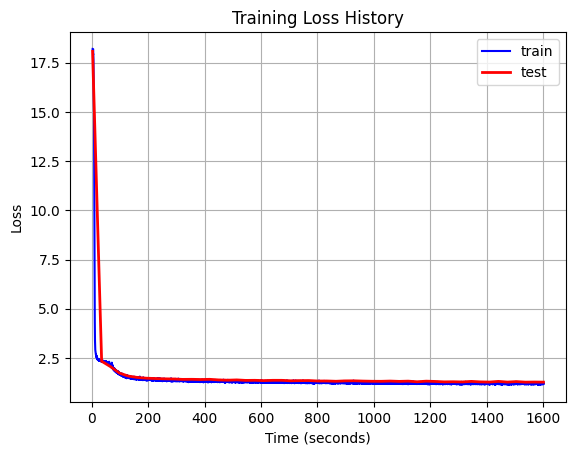

In [31]:
# plot the loss history
import matplotlib.pyplot as plt
plt.plot(time_history, loss_history, '-', label='train', color="blue")
plt.plot(time_test_history, loss_test_history, '-', label='test', lw=2, color="red")
plt.xlabel("Time (seconds)")
plt.ylabel("Loss")
plt.legend(loc='upper right')
plt.title("Training Loss History")
plt.grid()

In [33]:
B = 1
seed = 42
rng = jax.random.PRNGKey(seed)
prompt = "hello my fri"
prompt_int = jnp.array([ [char_to_int.get(c, len(char_set)) for c in prompt.lower()[:64]] ], dtype=jnp.int32)

gen_len = 1000
out_ids = generation.generate_tokens(model, params, rng, prompt_int, gen_len, block_size=64, 
                          temperature=0.7, sample=True)
print('generated ids shape:', out_ids.shape)
print('generated text:')
generated_text = ''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0]))
# concatenate with prompt
print(prompt + generated_text)
#print(''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0])))

generated ids shape: (1, 1000)
generated text:
hello my fri il s chimo as abo sh ai a on al nivapararadi crimes correspondence and separate university is a given monthly a continuous series the decision of the characters in the subject the state control of the interested it in any part duplicate accounts of scientific orbital subspecies of most license may be a personal feature this is not participate in some sources the drug in games seven zero s flood his own at the time and favor of the middle economic and circumference it is possible on the achievement of antithesis involuntary series state points of communities also used the family for the construction of the constitution and the church expressing another person he was sufficient to read even can professional institute of constantine and the first in the form of the rest of course part of the rest of the beatles participated by hypothesis as the objects of his collaboration in the world s nuclear interview works in two zero zero t